# Introduction

Introduction text / cells go here...

# Data setup

In [1]:
# !uv pip install gdown
# !uv pip install umap-learn

import gdown

In [2]:
model_zip_id = "1hRnULP7o8nOdWUzp4uJQcqnKZakuFJ3W"
output = "../reference_data/models/"
gdown.download(id=model_zip_id, output=output)

Downloading...
From (original): https://drive.google.com/uc?id=1hRnULP7o8nOdWUzp4uJQcqnKZakuFJ3W
From (redirected): https://drive.google.com/uc?id=1hRnULP7o8nOdWUzp4uJQcqnKZakuFJ3W&confirm=t&uuid=8cac0b65-1ba6-41b7-be46-bc13478645bb
To: /Users/vjx856/Documents/Git/integrative_post_gwas_methods_course/reference_data/models/ext_d_inf_moe_general_16L-FUS_multitask.zip
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.53G/1.53G [00:18<00:00, 81.0MB/s]


'../reference_data/models/ext_d_inf_moe_general_16L-FUS_multitask.zip'

In [3]:
penncath_hg38_id = "1d1phne1USPa7gkj7LOneyFH9zcGexvHs"
output = "../reference_data/"
gdown.download(id=penncath_hg38_id, output=output)

Downloading...
From (original): https://drive.google.com/uc?id=1d1phne1USPa7gkj7LOneyFH9zcGexvHs
From (redirected): https://drive.google.com/uc?id=1d1phne1USPa7gkj7LOneyFH9zcGexvHs&confirm=t&uuid=0494a2e7-84ae-4642-8ba4-729121ebffad
To: /Users/vjx856/Documents/Git/integrative_post_gwas_methods_course/reference_data/penncat_hg38.zip
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 143M/143M [00:01<00:00, 92.8MB/s]


'../reference_data/penncat_hg38.zip'

In [4]:
!unzip -o ../reference_data/penncat_hg38.zip -d ../reference_data/

Archive:  ../reference_data/penncat_hg38.zip
  inflating: ../reference_data//penncath_hg38/penncath.csv  
  inflating: ../reference_data//penncath_hg38/penncath.bim  
  inflating: ../reference_data//penncath_hg38/penncath.bed  
  inflating: ../reference_data//penncath_hg38/penncath.fam  


# Prediction

In [5]:
!eirautogppredict --genotype_data_path ../reference_data/penncath_hg38 --packed_experiment_path ../reference_data/models/ext_d_inf_moe_general_16L-FUS_multitask.zip --output_folder ../output

14:19:59 - WARNING - eir_auto_gp.predict.prepare_data - PLINK2/PLINK not available, skipping pre-filtering
14:19:59 - INFO - eir_auto_gp.predict.data_preparation_utils - Analyzing SNP overlap including strand/ambiguity checks...


                          SNP Overlap Analysis Report                           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric                                             ┃ Value                   ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ COVERAGE METRICS                                   │                         │
│   Original Training SNPs Recovered (Main)          │ 39.5%                   │
│   New Cohort SNPs Usable (of total)                │ 11.0%*                  │
│                                                    │                         │
│ MATCHING DETAILS                                   │                         │
│   Total Matching SNPs                 

# Analysis

## Imports and setup

In [6]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path("../output/results")
LABELS_PATH = Path("../reference_data/penncath_hg38/penncath.csv")

In [7]:
def load_trait_csv(path: Path) -> pd.Series:
  df = pd.read_csv(path).set_index("ID")
  trait = path.stem
  prob1 = [c for c in df.columns if c.endswith("Ensemble Prob 1")]
  if prob1:
      s = df[prob1[0]].rename(trait)
      s.attrs["kind"] = "binary"
      return s
  ensemble = [c for c in df.columns if re.fullmatch(rf"{re.escape(trait)} Ensemble", c)]
  if not ensemble:
      raise ValueError(f"No ensemble column found in {path.name}: {list(df.columns)}")
  s = df[ensemble[0]].rename(trait)
  s.attrs["kind"] = "continuous"
  return s

## Loading in the predictions

In [8]:
series_list, kinds = [], {}
for p in sorted(RESULTS_DIR.glob("*.csv")):
  s = load_trait_csv(p)
  series_list.append(s)
  kinds[s.name] = s.attrs["kind"]

preds = pd.concat(series_list, axis=1)
trait_kind = pd.Series(kinds, name="kind")
print(f"preds: {preds.shape}  continuous={(trait_kind=='continuous').sum()}  binary={(trait_kind=='binary').sum()}")
display(preds.head())

labels = pd.read_csv(LABELS_PATH).set_index("ID")
print(f"labels: {labels.shape}")
display(labels.head())

preds: (1401, 315)  continuous=237  binary=78


,Alanine_aminotransferase,Albumin_BIOCH,Alkaline_phosphatase,Apolipoprotein_A,Apolipoprotein_A1,Apolipoprotein_B_BIOCH,Apolipoprotein_B_METAB,Aspartate_aminotransferase,Average_Diameter_for_HDL_Particles,Average_Diameter_for_VLDL_Particles,...,Urea,VLDL_Cholesterol,Vitamin_D,Waist_circumference,Weight_ANTHRO,Weight_IMPED,White_blood_cell_leukocyte_count,Whole_body_fat_free_mass,Whole_body_fat_mass,Whole_body_water_mass
ID,,,,,,,,,,,,,,,,,,,,,
10002,22.542770,45.750916,78.095764,1.516815,1.461326,1.079866,0.920252,25.107138,9.593956,38.873093,...,5.371122,0.798058,49.158367,92.140720,80.537926,80.50510,6.893251,54.358200,26.746830,39.798134
10004,28.100965,44.744290,82.361750,1.553589,1.489705,0.935423,0.784924,26.449203,9.604637,38.699020,...,5.384340,0.621664,46.077310,88.349655,76.547020,76.31497,6.289234,52.096508,23.333853,37.992416
10005,22.484835,45.355780,90.182304,1.544894,1.473571,1.035341,0.870705,27.218803,9.558011,39.674297,...,5.420731,0.774767,50.846190,90.930590,76.097400,75.78765,6.923183,51.953293,26.081810,37.976200
10007,23.979660,45.518280,87.363410,1.639348,1.566334,1.016251,0.852204,24.755083,9.717244,38.340710,...,5.477870,0.692197,45.338993,87.590614,70.782000,70.52157,6.385489,49.508488,22.894985,36.236700
10008,26.343996,46.066658,88.195015,1.447073,1.392570,1.073851,0.893995,26.636324,9.563436,38.972090,...,5.484081,0.751684,54.548225,87.538030,78.507370,78.36777,6.650043,52.501266,23.214048,38.252075


labels: (1401, 6)


,CAD,sex,age,tg,hdl,ldl
ID,,,,,,
10002,1,1,60,NaN,NaN,NaN
10004,1,2,50,55.0,23.0,75.0
10005,1,1,55,105.0,37.0,69.0
10007,1,1,52,314.0,54.0,108.0
10008,1,1,58,161.0,40.0,94.0


In [9]:
continuous_traits = {
    'TG': 'Triglycerides',
    'HDL': 'HDL Cholesterol',
    'LDL': 'LDL Cholesterol'
}

binary_traits = {
    'CAD': 'Coronary Artery Disease'
}

In [10]:
rename_preds = {
    'I25': 'CAD_pred',
    'Total_Triglycerides': 'TG_pred',
    'HDL_cholesterol': 'HDL_pred',
    'LDL_Cholesterol': 'LDL_pred'
}

rename_true = {
    'CAD': 'CAD_true',
    'tg': 'TG_true',
    'hdl': 'HDL_true',
    'ldl': 'LDL_true'
}

preds_copy = preds.reset_index()
preds_copy = preds_copy[['ID'] + list(rename_preds.keys())].copy()
preds_renamed = preds_copy.rename(columns=rename_preds)
true_renamed = labels.rename(columns=rename_true)

merged_df = pd.merge(preds_renamed, true_renamed, on='ID', how='inner')
print(f"merged: {merged_df.shape}")
display(merged_df.head())

merged: (1401, 11)


,ID,CAD_pred,TG_pred,HDL_pred,LDL_pred,CAD_true,sex,age,TG_true,HDL_true,LDL_true
0,10002,0.299964,1.445587,1.431592,1.888146,1,1,60,NaN,NaN,NaN
1,10004,0.366859,1.230927,1.444633,1.623983,1,2,50,55.0,23.0,75.0
2,10005,0.418134,1.732881,1.349207,1.733176,1,1,55,105.0,37.0,69.0
3,10007,0.428991,1.272115,1.598767,1.763022,1,1,52,314.0,54.0,108.0
4,10008,0.453609,1.419624,1.304491,1.781938,1,1,58,161.0,40.0,94.0


## Evaluation of Continuous Traits

### Unit conversion (Converted): mmol/L → mg/dL

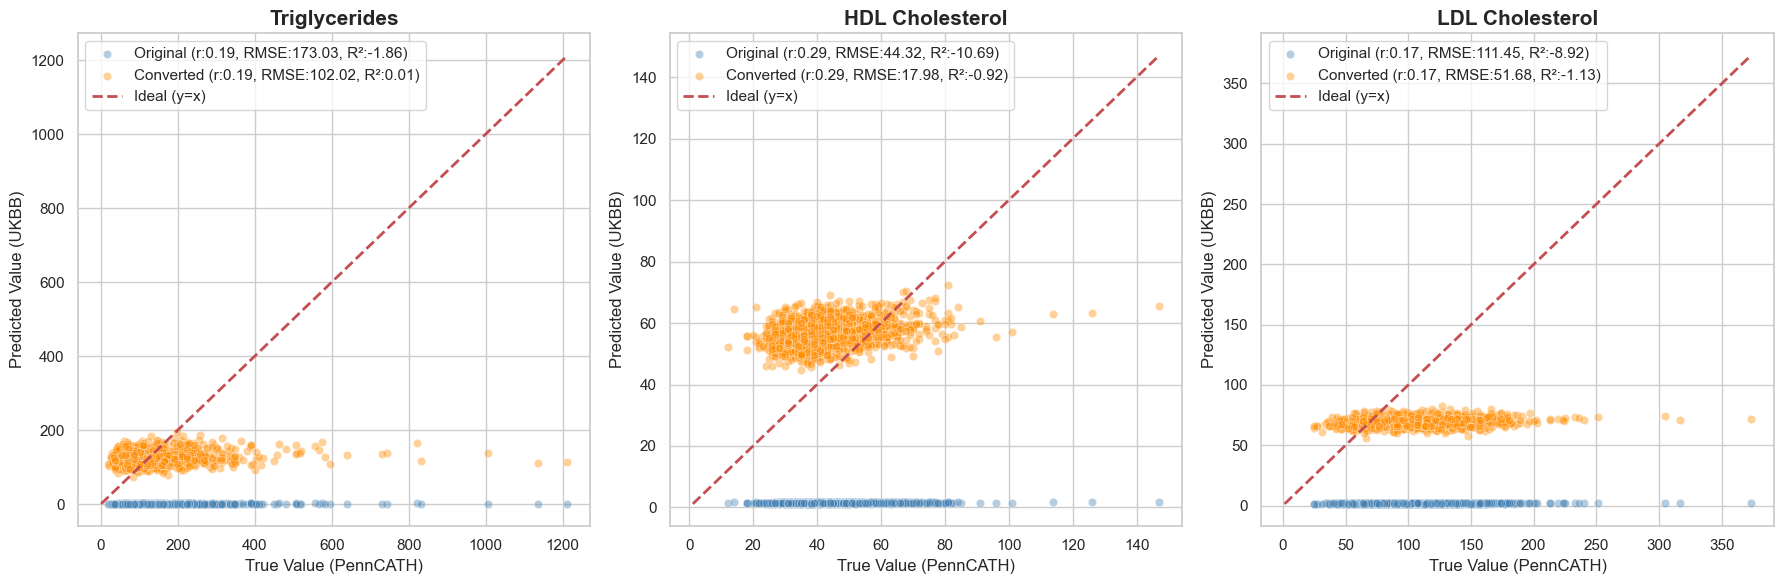

In [11]:
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, roc_curve, average_precision_score, precision_recall_curve, auc
from scipy.stats import pearsonr

sns.set_theme(style="whitegrid")

df_real_final = merged_df.copy()

# Unit conversion: mmol/L → mg/dL
df_real_final['TG_conv'] = df_real_final['TG_pred'] * 88.57
df_real_final['HDL_conv'] = df_real_final['HDL_pred'] * 38.67
df_real_final['LDL_conv'] = df_real_final['LDL_pred'] * 38.67

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, trait in enumerate(continuous_traits.keys()):
    cols = [f'{trait}_true', f'{trait}_pred', f'{trait}_conv']
    valid_data = df_real_final[cols].dropna()
    
    y_true = valid_data[f'{trait}_true']
    y_pred = valid_data[f'{trait}_pred']
    y_conv = valid_data[f'{trait}_conv']
    
    ax = axes[i]
    
    # --- True vs. Predicted (Original Scale) ---
    rmse_p = np.sqrt(mean_squared_error(y_true, y_pred))
    r2_p = r2_score(y_true, y_pred)
    corr_p, _ = pearsonr(y_true, y_pred)
    
    label_p = f'Original (r:{corr_p:.2f}, RMSE:{rmse_p:.2f}, R²:{r2_p:.2f})'
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.4, ax=ax, label=label_p, color='steelblue')

    # --- True vs. Converted (Converted Scale) ---
    rmse_c = np.sqrt(mean_squared_error(y_true, y_conv))
    r2_c = r2_score(y_true, y_conv)
    corr_c, _ = pearsonr(y_true, y_conv)
    
    label_c = f'Converted (r:{corr_c:.2f}, RMSE:{rmse_c:.2f}, R²:{r2_c:.2f})'
    sns.scatterplot(x=y_true, y=y_conv, alpha=0.4, ax=ax, label=label_c, color='darkorange')

    all_vals = pd.concat([y_true, y_pred, y_conv])
    min_val, max_val = all_vals.min(), all_vals.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal (y=x)')
    
    ax.set_title(continuous_traits[trait], fontsize=15, fontweight='bold')
    ax.set_xlabel('True Value (PennCATH)')
    ax.set_ylabel('Predicted Value (UKBB)')
    
    ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

### Z-score Standardized Comparison

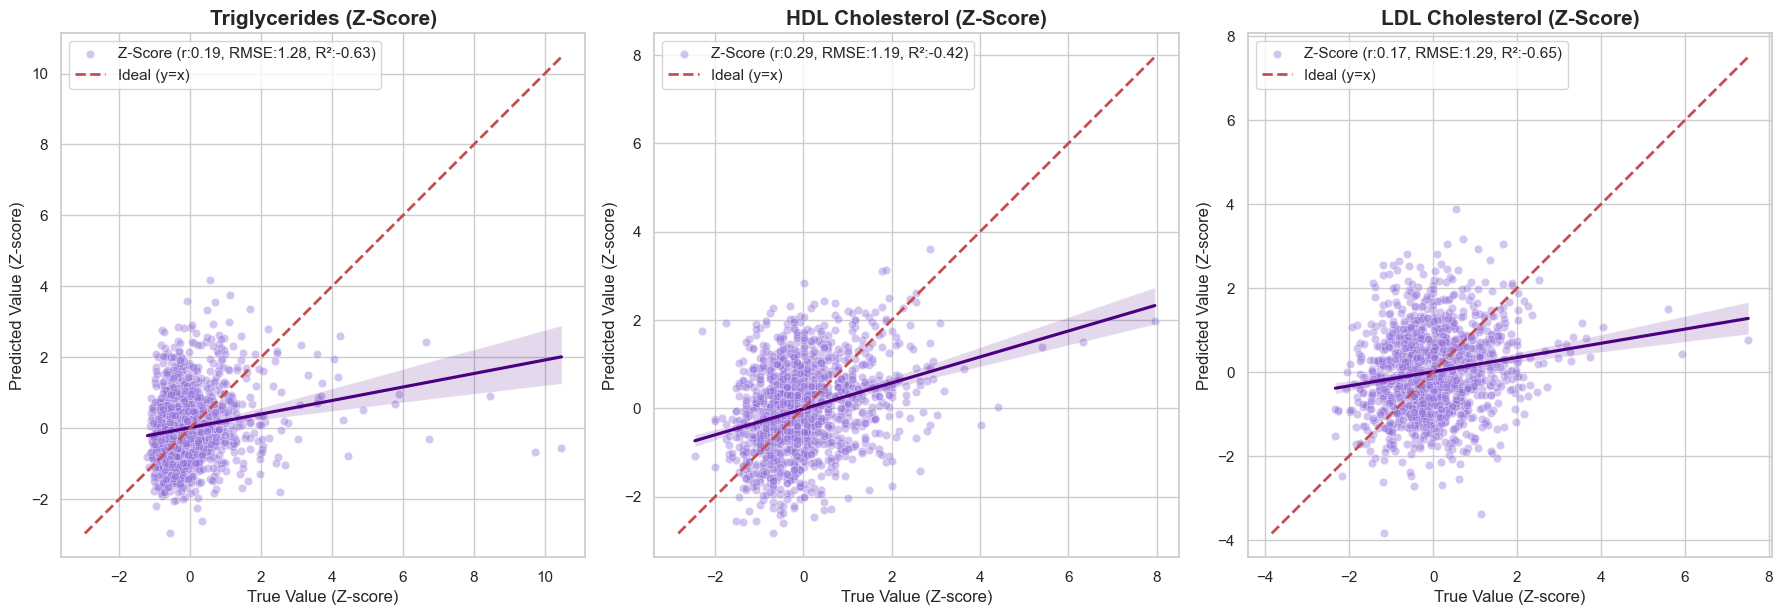

In [12]:
from sklearn.preprocessing import StandardScaler

df_zscore = df_real_final.copy()
scaler = StandardScaler()

for trait in continuous_traits.keys():
    df_zscore[f'{trait}_true_z'] = scaler.fit_transform(df_zscore[[f'{trait}_true']])
    df_zscore[f'{trait}_pred_z'] = scaler.fit_transform(df_zscore[[f'{trait}_pred']])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, trait in enumerate(continuous_traits.keys()):
    cols = [f'{trait}_true_z', f'{trait}_pred_z']
    valid_data = df_zscore[cols].dropna()
    
    y_true_z = valid_data[f'{trait}_true_z']
    y_pred_z = valid_data[f'{trait}_pred_z']
    
    ax = axes[i]
    
    rmse_z = np.sqrt(mean_squared_error(y_true_z, y_pred_z))
    r2_z = r2_score(y_true_z, y_pred_z)
    corr_z, _ = pearsonr(y_true_z, y_pred_z)
    
    label_z = f'Z-Score (r:{corr_z:.2f}, RMSE:{rmse_z:.2f}, R²:{r2_z:.2f})'
    
    sns.scatterplot(x=y_true_z, y=y_pred_z, alpha=0.4, ax=ax, label=label_z, color='mediumpurple')
    sns.regplot(x=y_true_z, y=y_pred_z, scatter=False, ax=ax, color='indigo', 
                line_kws={'label': f'Trend (r={r2_z:.3f})'})
 
    all_vals = pd.concat([y_true_z, y_pred_z])
    min_val, max_val = all_vals.min(), all_vals.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal (y=x)')
    
    ax.set_title(f'{continuous_traits[trait]} (Z-Score)', fontsize=15, fontweight='bold')
    ax.set_xlabel('True Value (Z-score)')
    ax.set_ylabel('Predicted Value (Z-score)')
    
    ax.legend(loc='upper left', fontsize=11)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

In [13]:
import statsmodels.formula.api as smf

df = df_real_final.copy()

for trait, full_name in continuous_traits.items():
    y_col = f"{trait}_true"
    prs_col = f"{trait}_conv"
    
    # Base Model (age + sex)
    formula_base = f"{y_col} ~ age + sex"
    model_base = smf.ols(formula=formula_base, data=df).fit()
    r2_base = model_base.rsquared * 100
    
    # Full Model
    formula_full = f"{y_col} ~ age + sex + {prs_col}"
    model_full = smf.ols(formula=formula_full, data=df).fit()
    r2_full = model_full.rsquared * 100
    
    # Delta R2
    delta_r2 = r2_full - r2_base
    
    # P-value for the PRS term in the full model
    p_val_prs = model_full.pvalues[prs_col]
    
    print(f"[{trait} - {full_name}]")
    print(f" - Base R2 (age, sex): {r2_base:.2f}%")
    print(f" - Full R2 (+ PRS)  : {r2_full:.2f}%")
    print(f" - Delta R2         : +{delta_r2:.2f}% (p-value: {p_val_prs:.2e})\n")

[TG - Triglycerides]
 - Base R2 (age, sex): 2.91%
 - Full R2 (+ PRS)  : 5.74%
 - Delta R2         : +2.84% (p-value: 5.02e-10)

[HDL - HDL Cholesterol]
 - Base R2 (age, sex): 15.60%
 - Full R2 (+ PRS)  : 22.24%
 - Delta R2         : +6.64% (p-value: 4.75e-25)

[LDL - LDL Cholesterol]
 - Base R2 (age, sex): 1.80%
 - Full R2 (+ PRS)  : 4.70%
 - Delta R2         : +2.89% (p-value: 6.39e-10)



## Evaluation of Binary Traits

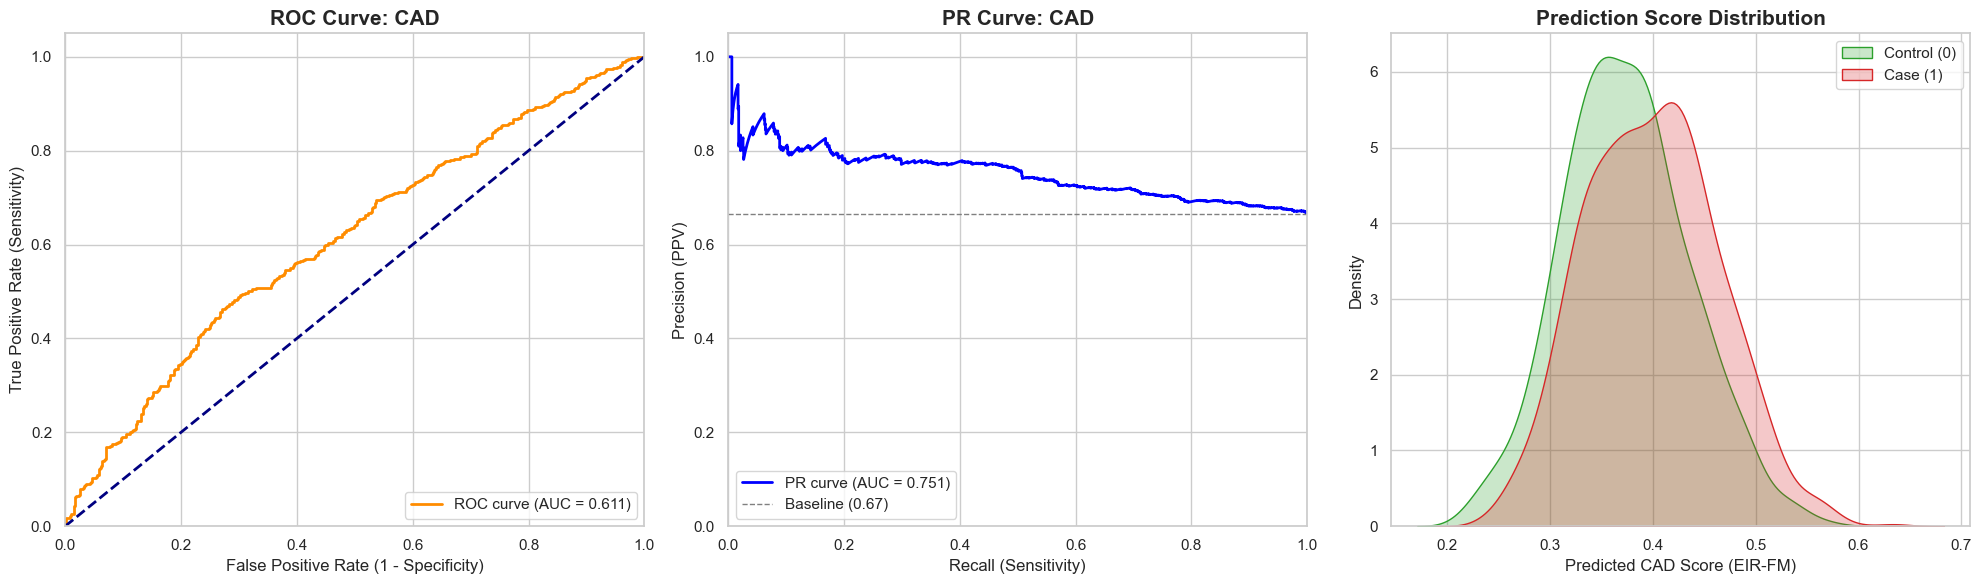

In [14]:
for trait, full_name in binary_traits.items():
    true_col = f'{trait}_true'
    pred_col = f'{trait}_pred'
    
    valid_data = df[[true_col, pred_col]].dropna()
    y_true = valid_data[true_col]
    y_score = valid_data[pred_col]
    
    roc_auc = roc_auc_score(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall, precision)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    axes[0].set_title(f'ROC Curve: {trait}', fontsize=15, fontweight='bold')
    axes[0].legend(loc="lower right", fontsize=11)

    axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    baseline = y_true.sum() / len(y_true)
    axes[1].axhline(y=baseline, color='gray', linestyle='--', lw=1, label=f'Baseline ({baseline:.2f})')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12)
    axes[1].set_ylabel('Precision (PPV)', fontsize=12)
    axes[1].set_title(f'PR Curve: {trait}', fontsize=15, fontweight='bold')
    axes[1].legend(loc="lower left", fontsize=11)

    sns.kdeplot(data=valid_data[valid_data[true_col] == 0][pred_col], 
                ax=axes[2], fill=True, color='#2ca02c', label='Control (0)')
    sns.kdeplot(data=valid_data[valid_data[true_col] == 1][pred_col], 
                ax=axes[2], fill=True, color='#d62728', label='Case (1)')
    axes[2].set_title(f'Prediction Score Distribution', fontsize=15, fontweight='bold')
    axes[2].set_xlabel(f'Predicted {trait} Score (EIR-FM)', fontsize=12)
    axes[2].set_ylabel('Density', fontsize=12)
    axes[2].legend(loc='upper right', fontsize=11)

    plt.tight_layout()
    plt.show()

In [15]:
for trait, full_name in binary_traits.items():
    y_col = f"{trait}_true"
    pred_col = f"{trait}_pred"

    # Base Model (age + sex)
    formula_base = f"{y_col} ~ age + sex"
    logit_base = smf.logit(formula=formula_base, data=df).fit(disp=0)
    
    auc_base = roc_auc_score(df[y_col], logit_base.predict(df))
    pseudo_r2_base = logit_base.prsquared * 100

    # Full Model
    formula_full = f"{y_col} ~ age + sex + {pred_col}"
    logit_full = smf.logit(formula=formula_full, data=df).fit(disp=0)
    
    auc_full = roc_auc_score(df[y_col], logit_full.predict(df))
    pseudo_r2_full = logit_full.prsquared * 100

    delta_auc = auc_full - auc_base
    delta_pseudo_r2 = pseudo_r2_full - pseudo_r2_base
    
    p_val_score = logit_full.pvalues[pred_col]

    print(f"[{trait} - {full_name}]")
    print(f" - Base Model (age, sex)")
    print(f"   * AUC: {auc_base:.4f} | Pseudo-R²: {pseudo_r2_base:.2f}%")
    
    print(f" - Full Model (+ {trait} Score)")
    print(f"   * AUC: {auc_full:.4f} | Pseudo-R²: {pseudo_r2_full:.2f}%")
    
    print(f" - Incremental Gain (Delta)")
    print(f"   * Delta AUC: +{delta_auc:.4f}")
    print(f"   * Delta R² : +{delta_pseudo_r2:.2f}% (p-value: {p_val_score:.2e})\n")

[CAD - Coronary Artery Disease]
 - Base Model (age, sex)
   * AUC: 0.7778 | Pseudo-R²: 20.51%
 - Full Model (+ CAD Score)
   * AUC: 0.7881 | Pseudo-R²: 21.96%
 - Incremental Gain (Delta)
   * Delta AUC: +0.0102
   * Delta R² : +1.45% (p-value: 5.84e-07)



## Clustering correlated traits

/Users/vjx856/Documents/Git/integrative_post_gwas_methods_course/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/vjx856/Documents/Git/integrative_post_gwas_methods_course/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


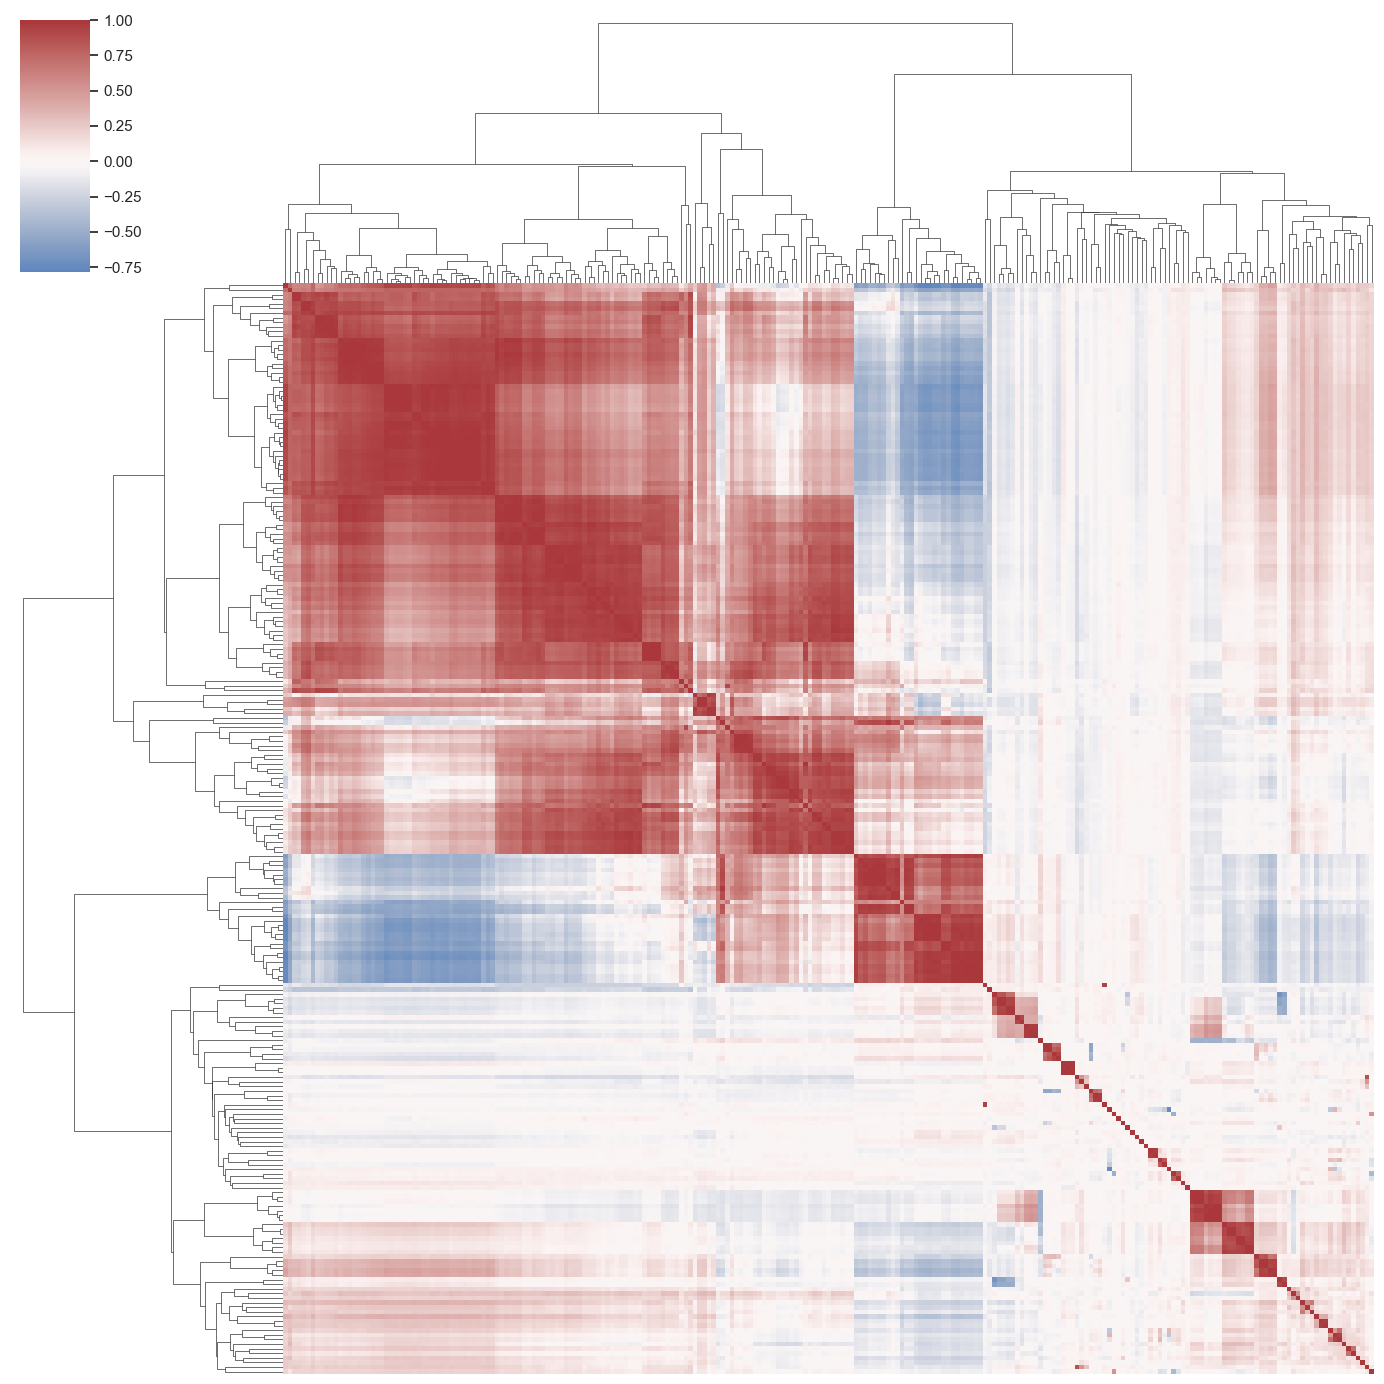

Continuous traits in correlation: 237


In [16]:
df = preds.copy()

cont_traits = trait_kind.index[trait_kind == "continuous"].tolist()
cont = df[cont_traits].apply(pd.to_numeric, errors="coerce")
cont = cont.loc[:, cont.std() > 0]
corr = cont.corr(method="spearman")

order = sns.clustermap(corr, cmap="vlag", center=0, figsize=(14, 14),
                    xticklabels=False, yticklabels=False).dendrogram_row.reordered_ind
plt.show()
print(f"Continuous traits in correlation: {corr.shape[0]}")

In [17]:
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = (corr.where(mask).stack()
            .rename("spearman").reset_index()
            .rename(columns={"level_0": "trait_a", "level_1": "trait_b"}))
pairs["abs_r"] = pairs["spearman"].abs()
pairs.sort_values("abs_r", ascending=False).head(20)

,trait_a,trait_b,spearman,abs_r
27951,Weight_ANTHRO,Weight_IMPED,0.997179,0.997179
4328,Cholesterol_in_Large_HDL,Cholesteryl_Esters_in_Large_HDL,0.996765,0.996765
13564,Concentration_of_Very_Small_VLDL_Particles,Total_Lipids_in_Very_Small_VLDL,0.996750,0.996750
24926,Phospholipids_in_Very_Small_VLDL,Total_Lipids_in_Very_Small_VLDL,0.996470,0.996470
2766,Body_mass_index_BMI_ANTHRO,Body_mass_index_BMI_IMPED,0.996365,0.996365
12874,Concentration_of_Small_VLDL_Particles,Total_Lipids_in_Small_VLDL,0.996149,0.996149
6246,Cholesterol_in_Very_Large_HDL,Cholesteryl_Esters_in_Very_Large_HDL,0.996089,0.996089
4753,Cholesterol_in_Large_VLDL,Cholesterol_in_Very_Large_VLDL,0.995785,0.995785
23911,Phospholipids_in_Large_HDL,Total_Lipids_in_Large_HDL,0.995528,0.995528
24767,Phospholipids_in_Very_Large_HDL,Total_Lipids_in_Very_Large_HDL,0.995453,0.995453


## Cluster visualization

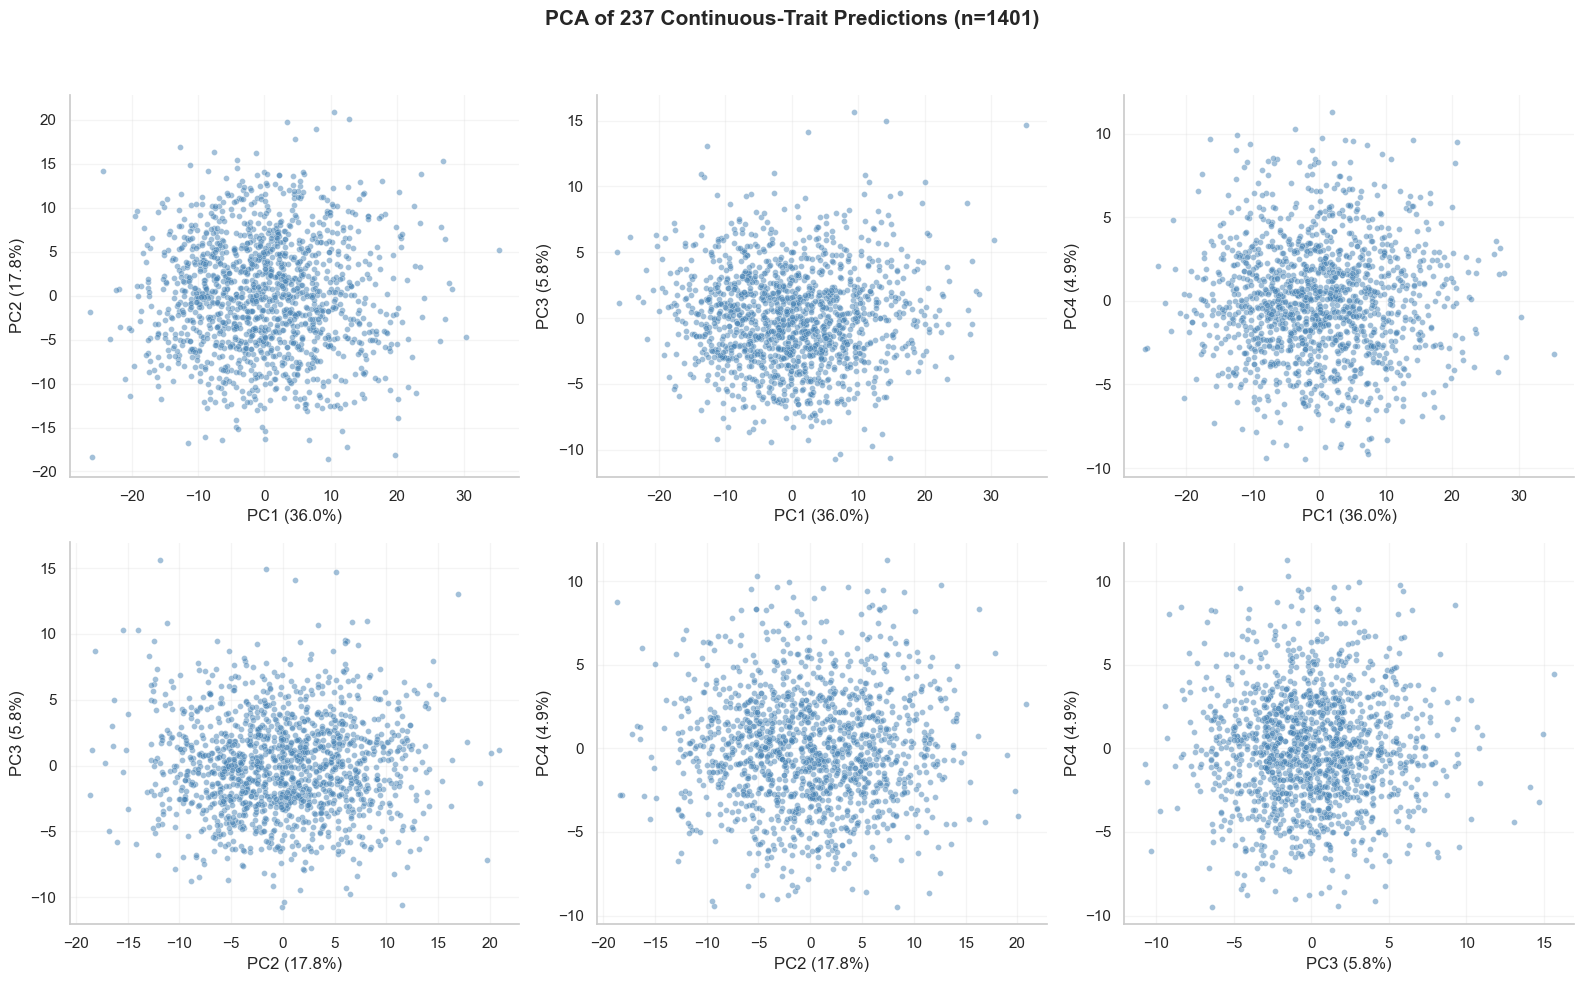

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from itertools import combinations

X_df = df[cont.columns].dropna(axis=1, thresh=int(0.95 * len(df)))
X = StandardScaler().fit_transform(X_df.values)

pca = PCA(n_components=4, random_state=0)
pcs = pca.fit_transform(X)
pc_df = pd.DataFrame(pcs, columns=[f"PC{i+1}" for i in range(4)], index=X_df.index)

pairs = list(combinations(range(1, 5), 2))
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (i, j) in zip(axes.flat, pairs):
    ax.scatter(pc_df[f"PC{i}"], pc_df[f"PC{j}"],
               s=18, alpha=0.5, linewidth=0.3,
               edgecolor="white", color='steelblue') 
    
    var_i = pca.explained_variance_ratio_[i-1]
    var_j = pca.explained_variance_ratio_[j-1]
    
    ax.set_xlabel(f"PC{i} ({var_i*100:.1f}%)")
    ax.set_ylabel(f"PC{j} ({var_j*100:.1f}%)")
    
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2)

fig.suptitle(f"PCA of {X_df.shape[1]} Continuous-Trait Predictions (n={len(pc_df)})", 
             fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

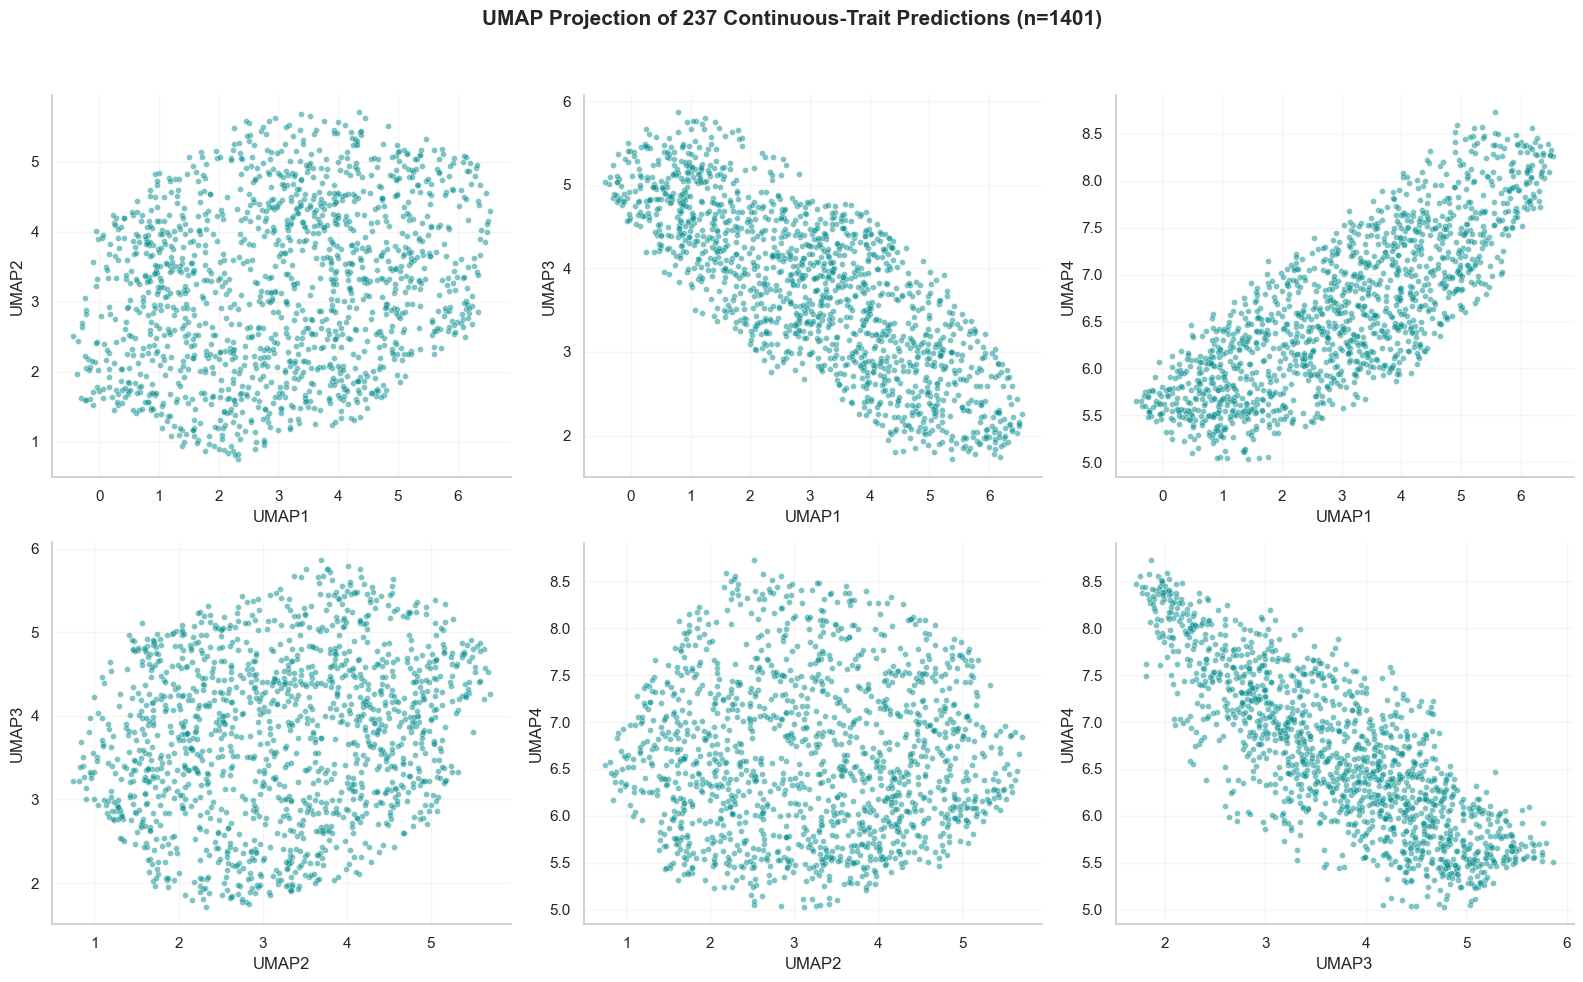

In [19]:
import umap

reducer = umap.UMAP(n_components=4, n_neighbors=30, min_dist=0.3,
                    metric="euclidean", random_state=42, n_jobs=1)

emb = reducer.fit_transform(X)
um_df = pd.DataFrame(emb, columns=[f"UMAP{i+1}" for i in range(4)], index=X_df.index)

pairs = list(combinations(range(1, 5), 2))
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (i, j) in zip(axes.flat, pairs):
    ax.scatter(um_df[f"UMAP{i}"], um_df[f"UMAP{j}"],
               s=18, alpha=0.5, linewidth=0.3,
               edgecolor="white", color='darkcyan')
    
    ax.set_xlabel(f"UMAP{i}")
    ax.set_ylabel(f"UMAP{j}")
    
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2)

fig.suptitle(f"UMAP Projection of {X_df.shape[1]} Continuous-Trait Predictions (n={len(um_df)})",
             fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()